In [77]:
# Imports
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import PathPatch
from matplotlib.path import Path

In [78]:
# Global plot style
matplotlib.rcParams.update({
    'font.family': 'DejaVu Serif',
    'font.size': 14,
    'axes.labelweight': 'medium',
    'xtick.labelsize': 13,
    'ytick.labelsize': 12
})

In [79]:
# Paths
SPATIAL_GRIDS_DIR = "../1_data/processed/spatial_grids"
CELL_ZONES_PATH = "../1_data/processed/cell_zones.parquet"
SHAPEFILE_PATH = "../1_data/raw/WarningAreas/WarningAreas.shp"
SAVE_DIR = "plots/spatial_maps"
os.makedirs(SAVE_DIR, exist_ok=True)

In [80]:
# Load precomputed grids
fire_counts_total = np.load(os.path.join(SPATIAL_GRIDS_DIR, "fire_counts_total.npy"))

print("Fire grid shape:", fire_counts_total.shape, "| Max:", fire_counts_total.max())

Fire grid shape: (2592, 1490) | Max: 8


In [81]:
# Load zone shapefile
gdf_zones = gpd.read_file(SHAPEFILE_PATH)
gdf_zones = gdf_zones[gdf_zones.geometry.is_valid]
gdf_region = gdf_zones.dissolve()
xmin, ymin, xmax, ymax = gdf_zones.total_bounds

In [82]:
# Load cell-zone mapping
df_cell_zones = pd.read_parquet(CELL_ZONES_PATH)

In [83]:
gdf_zones = gpd.read_file(SHAPEFILE_PATH)
gdf_zones = gdf_zones[gdf_zones.geometry.is_valid]

In [84]:
# %%
gdf_zones = gpd.read_file(SHAPEFILE_PATH)
gdf_zones['geometry'] = gdf_zones['geometry'].buffer(0)
gdf_zones = gdf_zones[~gdf_zones.geometry.is_empty]
gdf_region = gdf_zones.dissolve()
xmin, ymin, xmax, ymax = gdf_zones.total_bounds
print(gdf_zones['id'].tolist())

[5, 7, 2, 4, 3, 6, 8, 1]


Fire frequency map saved


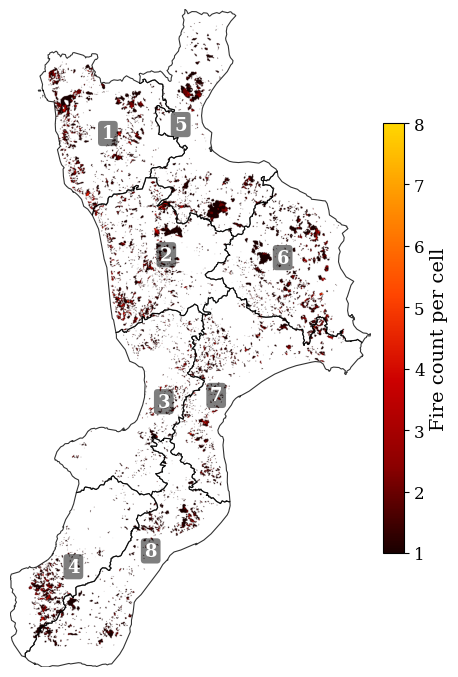

In [85]:
# Fire frequency map
masked_fire = np.ma.masked_where(fire_counts_total == 0, fire_counts_total)

cmap_fire = LinearSegmentedColormap.from_list(
    "fire_red",
    ["#1a0000", "#8b0000", "#cc0000", "#ff4500", "#ff8c00", "#ffd700"],
    N=256
)
cmap_fire.set_bad(color="white")

fig, ax = plt.subplots(figsize=(7, 7), facecolor="#FFFFFF")
ax.set_facecolor("white")
ax.set_axis_off()

im = ax.imshow(masked_fire, origin="upper", cmap=cmap_fire,
               extent=[xmin, xmax, ymin, ymax])

clip_geom = gdf_region.geometry.iloc[0]
clip_path = Path.make_compound_path(*[
    Path(np.array(poly.exterior.coords))
    for poly in (clip_geom.geoms if hasattr(clip_geom, 'geoms') else [clip_geom])
])
clip_patch = PathPatch(clip_path, transform=ax.transData)
im.set_clip_path(clip_patch)

gdf_zones.boundary.plot(ax=ax, color="black", linewidth=0.8, alpha=0.8)

for idx, row in gdf_zones.iterrows():
    point = row.geometry.representative_point()
    ax.text(point.x, point.y, str(row['id']),
            fontsize=13, fontweight='bold', ha='center', va='center',
            color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5, edgecolor='none'))

cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Fire count per cell", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fire_frequency_map.png"), dpi=300, bbox_inches="tight")
print("Fire frequency map saved")